In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Cargar Dataset

In [2]:
df = pd.read_csv('../data/brasil_dataset.csv', sep=";")

print(f'Shape: {df.shape}')
print(f'\nColumnas: {df.columns.tolist()}')
print(f'\nTipos de datos:')
print(df.dtypes)
df.head()

Shape: (100000, 66)

Columnas: ['transaction_id', 'bank_code', 'bank_name', 'bank_country', 'bank_tier', 'client_id', 'client_segment', 'channel', 'card_brand', 'pan_masked', 'pan_hash', 'MTI', 'DE2_PAN', 'DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE7_transmission_datetime', 'DE9_conversion_rate_billing', 'DE11_STAN', 'DE12_local_time', 'DE13_local_date', 'DE14_expiration_date', 'DE15_settlement_date', 'DE18_merchant_category_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number', 'DE25_pos_condition_code', 'DE32_acquiring_institution_id', 'DE35_track2_data_masked', 'DE37_retrieval_reference_number', 'DE38_authorization_code', 'DE39_response_code', 'DE41_terminal_id', 'DE42_card_acceptor_id', 'DE43_card_acceptor_name_location', 'DE44_additional_response_data', 'DE48_additional_data', 'DE49_currency_code_transaction', 'DE50_currency_code_settlement', 'DE51_currency_code_billing', 'DE52_pin_data_present', 'DE54_additiona

,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,...,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud
0,49b290bb-4479-4367-950d-ed7d9bdc96d0,BR-PRI,BR-PRI,BR,privado,BR-PRI-CL-00003011,CLASICA,POS,VISA,422355******4250,...,14.92,False,12.1,21,Tue,True,Approved,714.74,CURITIBA,False
1,0697c7b6-b5ab-4ab5-8684-4f3fcdd54ff2,BR-PRI,BR-PRI,BR,privado,BR-PRI-CL-00000292,ORO,POS,VISA,422355******2908,...,58.32,False,2.1,21,Tue,True,Approved,640.67,CURITIBA,False
2,ac73c4c0-ca7d-48b8-ad18-ab6dcc48819c,BR-PRI,BR-PRI,BR,privado,BR-PRI-CL-00002993,CLASICA,ATM,MASTERCARD,541333******2878,...,49.90,False,1086.0,21,Tue,True,Approved,626.32,RECIFE,False
3,b0e4e6d3-9b43-44c8-8fd2-37598de9aaad,BR-PRI,BR-PRI,BR,privado,BR-PRI-CL-00002693,CLASICA,ATM,VISA,422355******0490,...,40.97,False,22.6,21,Tue,True,Approved,278.19,RIODEJANEIRO,False
4,557549be-eed1-476d-8a1d-f6a2ae02518f,BR-PRI,BR-PRI,BR,privado,BR-PRI-CL-00000045,PLATINO,POS,MASTERCARD,533421******0731,...,71.60,True,6671.0,21,Tue,True,Approved,664.09,PORTOALEGRE,False


El dataset de Brasil fue cargado correctamente utilizando punto y coma (`;`) como separador, resultando
en un DataFrame de 100,000 transacciones y 66 variables, estructura idéntica al dataset de Bolivia. Los
tipos de datos son consistentes entre ambos datasets: variables numéricas (float64, int), booleanas
(`approved`, `is_fraud`) y categóricas (object). Esta uniformidad en la estructura es relevante para el
modelo federado, ya que facilita la alineación de features entre bancos. Al igual que en Bolivia, se
esperan valores nulos en columnas como `card_brand` y `response_description` que deberán tratarse en
el preprocesamiento.

# Variable Objetivo

In [3]:
target_candidates = [c for c in df.columns if c.lower() in ['fraud', 'isfraud', 'is_fraud', 'label', 'class', 'target', 'fraude']]
target_col = target_candidates[0] if target_candidates else df.columns[-1]
print(f"Variable objetivo detectada: '{target_col}'")

Variable objetivo detectada: 'is_fraud'


In [4]:
counts = df[target_col].value_counts()
pcts   = df[target_col].value_counts(normalize=True) * 100

dist = pd.DataFrame({
    'Clase': counts.index,
    'Conteo': counts.values,
    'Porcentaje': pcts.values.round(4)
})
print(dist.to_string(index=False))

 Clase  Conteo  Porcentaje
 False   96795      96.795
  True    3205       3.205


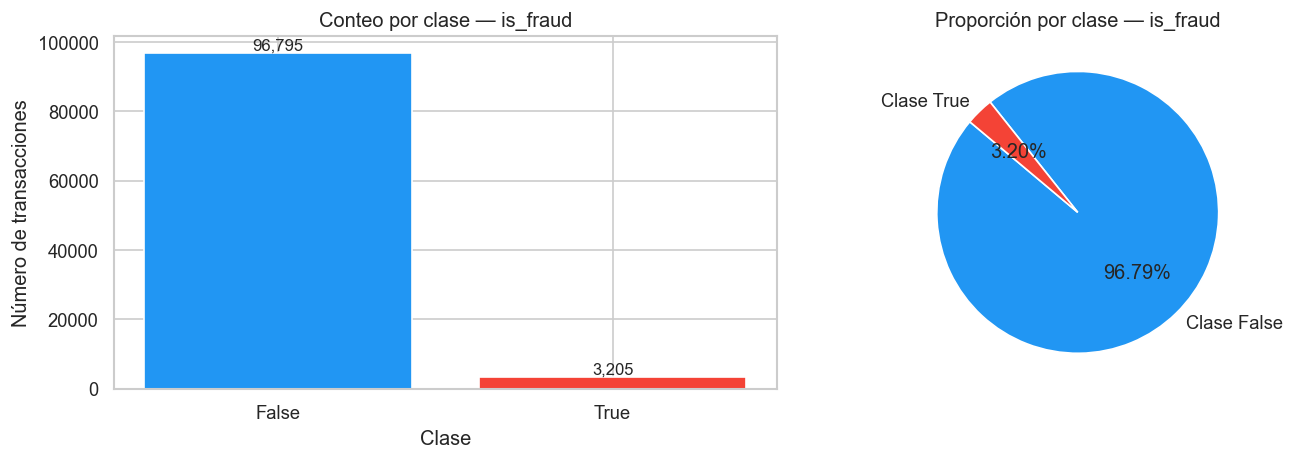

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2196F3', '#F44336']

# Bar chart
axes[0].bar(counts.index.astype(str), counts.values, color=colors[:len(counts)])
axes[0].set_title(f'Conteo por clase — {target_col}')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Número de transacciones')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + counts.max()*0.01, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(
    counts.values,
    labels=[f'Clase {c}' for c in counts.index],
    autopct='%1.2f%%',
    colors=colors[:len(counts)],
    startangle=140
)
axes[1].set_title(f'Proporción por clase — {target_col}')

plt.tight_layout()
plt.show()

La variable objetivo `is_fraud` fue detectada correctamente, con valores booleanos `True` y `False`.
El dataset de Brasil presenta 96,795 transacciones legítimas (96.80%) y 3,205 fraudulentas (3.20%),
mostrando un desbalanceo mayor al de Bolivia (4.92%). Esto indica que el patrón de fraude en Brasil
es menos frecuente proporcionalmente, lo cual representa un desafío adicional para el modelo federado
ya que cada banco tiene una distribución de fraude distinta. Las visualizaciones confirman que la clase
minoritaria es aún más reducida que en Bolivia, lo que refuerza la necesidad de estrategias de balanceo
durante el entrenamiento.

# Metrica de Desbalanceo

In [6]:
majority = counts.max()
minority = counts.min()
imbalance_ratio = majority / minority

print(f'Clase mayoritaria : {counts.idxmax()} — {majority:,} muestras ({pcts[counts.idxmax()]:.2f}%)')
print(f'Clase minoritaria  : {counts.idxmin()} — {minority:,} muestras ({pcts[counts.idxmin()]:.2f}%)')
print(f'Imbalance ratio    : {imbalance_ratio:.2f}:1')

if imbalance_ratio < 2:
    nivel = 'Balanceado'
elif imbalance_ratio < 10:
    nivel = 'Desbalanceo moderado'
elif imbalance_ratio < 100:
    nivel = 'Desbalanceo severo'
else:
    nivel = 'Desbalanceo extremo'

print(f'Nivel de desbalanceo: {nivel}')

Clase mayoritaria : False — 96,795 muestras (96.80%)
Clase minoritaria  : True — 3,205 muestras (3.21%)
Imbalance ratio    : 30.20:1
Nivel de desbalanceo: Desbalanceo severo


Las métricas de desbalanceo confirman una situación más crítica que en Bolivia. El ratio de 30.20:1
significa que por cada transacción fraudulenta existen 30 legítimas, clasificándose también como
desbalanceo severo pero significativamente más pronunciado. Comparado con Bolivia (19.33:1), Brasil
presenta un 56% más de desbalanceo, lo que implica que el modelo federado deberá manejar distribuciones
de fraude heterogéneas entre bancos. Un clasificador naive que prediga siempre `False` alcanzaría un
96.80% de accuracy, haciendo aún más crítico el uso de métricas alternativas como F1-score y AUC-ROC,
y un `scale_pos_weight = 30.20` como punto de partida para LightGBM.

# Distribucion de Variables Numericas por Clase

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop(target_col, errors='ignore').tolist()
print(f'Variables numéricas ({len(num_cols)}): {num_cols}\n')

df.groupby(target_col)[num_cols].describe().T

Variables numéricas (35): ['MTI', 'DE2_PAN', 'DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE7_transmission_datetime', 'DE9_conversion_rate_billing', 'DE11_STAN', 'DE12_local_time', 'DE13_local_date', 'DE14_expiration_date', 'DE15_settlement_date', 'DE18_merchant_category_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number', 'DE25_pos_condition_code', 'DE32_acquiring_institution_id', 'DE39_response_code', 'DE48_additional_data', 'DE49_currency_code_transaction', 'DE50_currency_code_settlement', 'DE51_currency_code_billing', 'DE54_additional_amounts', 'DE56_original_data', 'DE58_authorizing_agent_id', 'DE61_pos_extended_data', 'DE100_receiving_institution_id', 'DE103_account_id_2', 'amount_local', 'amount_tx_currency', 'amount_usd', 'distance_from_home_km', 'hour_local', 'client_baseline_amount']



is_fraud                         False    True 
MTI                    count  96795.00  3205.00
                       mean     100.00   100.00
                       std        0.00     0.00
                       min      100.00   100.00
                       25%      100.00   100.00
...                                ...      ...
client_baseline_amount min      250.06   250.06
                       25%      415.67   419.24
                       50%      576.63   577.42
                       75%      740.05   739.72
                       max      899.99   899.99

[280 rows x 2 columns]

In [8]:
means = df.groupby(target_col)[num_cols].mean()
diff = (means.loc[True] - means.loc[False]).abs()
diff_pct = (diff / means.loc[False].replace(0, np.nan) * 100).round(2)

resumen = pd.DataFrame({
    'mean_legit': means.loc[False].round(4),
    'mean_fraud': means.loc[True].round(4),
    'diff_abs': diff.round(4),
    'diff_pct': diff_pct
}).sort_values('diff_pct', ascending=False)

print(resumen.head(15).to_string())

                                  mean_legit    mean_fraud      diff_abs  diff_pct
DE4_amount_transaction          2.286123e+05  2.930069e+06  2.701457e+06   1181.68
amount_tx_currency              2.286123e+03  2.930069e+04  2.701457e+04   1181.68
DE39_response_code              1.000300e+00  8.698000e+00  7.697700e+00    769.55
distance_from_home_km           9.554068e+02  4.291258e+03  3.335851e+03    349.16
DE19_acquirer_country_code      1.355981e+02  3.870977e+02  2.514996e+02    185.47
amount_usd                      1.339157e+02  3.467382e+02  2.128225e+02    158.92
DE6_amount_cardholder_billing   6.695787e+04  1.733691e+05  1.064112e+05    158.92
amount_local                    6.695787e+02  1.733691e+03  1.064112e+03    158.92
DE9_conversion_rate_billing     1.378642e+07  2.947867e+07  1.569225e+07    113.82
DE61_pos_extended_data          2.099430e+01  3.348600e+01  1.249170e+01     59.50
DE25_pos_condition_code         2.100800e+01  3.344870e+01  1.244070e+01     59.22
DE49

C:\Users\thiag\AppData\Local\Temp\ipykernel_25504\42062771.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\thiag\AppData\Local\Temp\ipykernel_25504\42062771.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\thiag\AppData\Local\Temp\ipykernel_25504\42062771.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\thiag\AppData\Local\Temp\ipykernel_25504\42062771.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

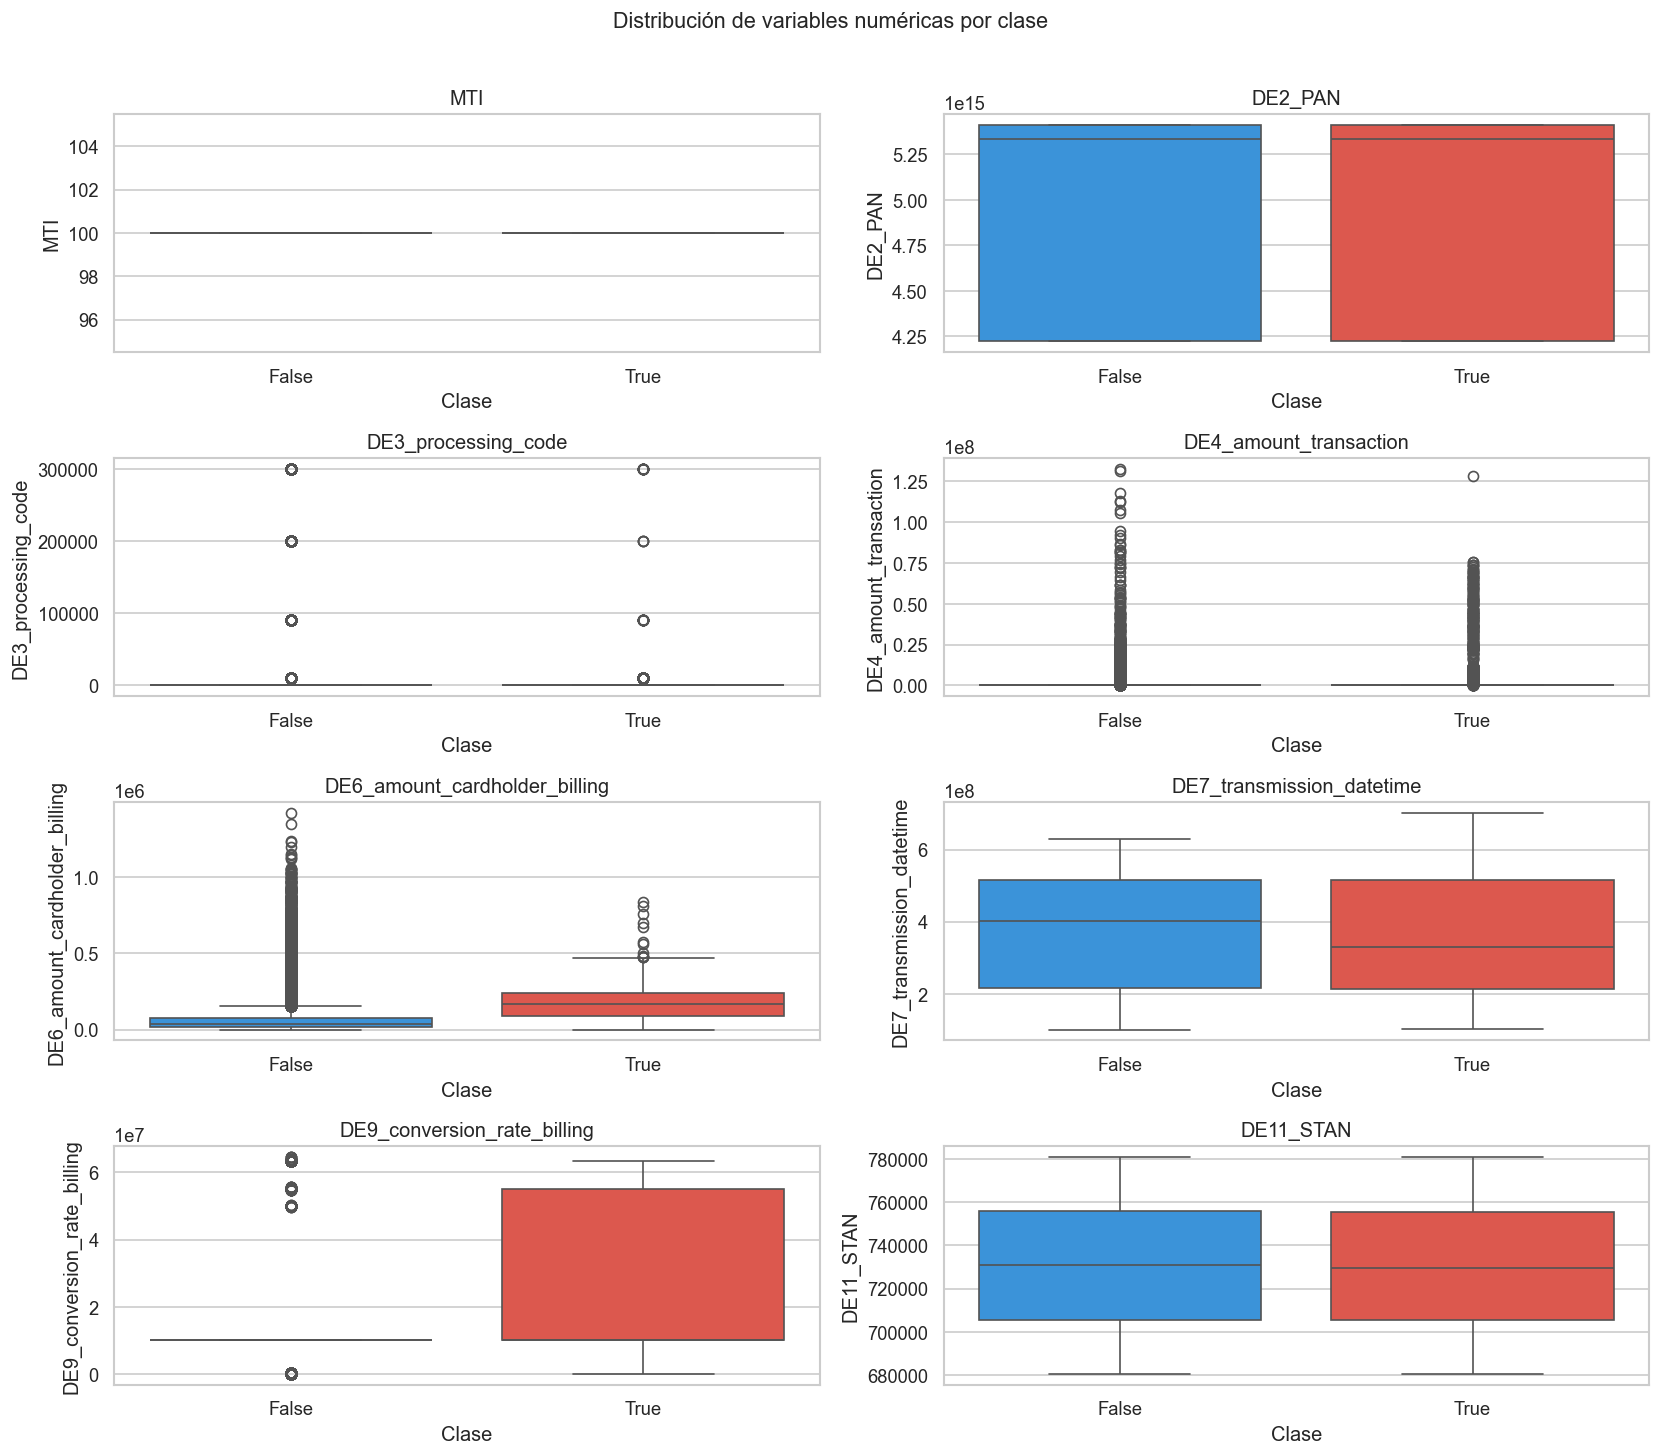

In [9]:
plot_cols = num_cols[:8]
n = len(plot_cols)
cols_grid = 2
rows_grid = (n + 1) // cols_grid

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(14, rows_grid * 3))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.boxplot(
        data=df, x=target_col, y=col,
        palette=['#2196F3', '#F44336'],
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('Clase')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas por clase', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

El análisis de variables numéricas en Brasil muestra patrones similares a Bolivia pero con diferencias
en magnitud. El monto de transacción (`DE4_amount_transaction`, `amount_tx_currency`) presenta la mayor
diferencia con 1181%, superando ampliamente el 439% observado en Bolivia, lo que indica que en Brasil
el fraude se concentra en transacciones de montos aún más elevados relativamente. `distance_from_home_km`
muestra una diferencia de 349% frente al 68% de Bolivia, sugiriendo que el fraude en Brasil ocurre
proporcionalmente mucho más lejos del domicilio del cliente. `DE39_response_code` nuevamente aparece
como variable de alta diferencia (769%) y debe tratarse con la misma cautela por riesgo de data leakage.
`MTI` y `DE11_STAN` continúan siendo variables sin poder discriminativo, consistente con Bolivia.

# Distribucion de Variables Categoricas por Clase

In [10]:
cat_cols = ['channel', 'card_brand', 'DE22_pos_entry_mode', 'DE25_pos_condition_code', 'bank_tier', 'client_segment']

for col in cat_cols:
    fraud_rate = df.groupby(col)[target_col].mean().sort_values(ascending=False)
    print(f"\n{col}:")
    print(fraud_rate.round(4))


channel:
channel
ECOM    0.0509
ATM     0.0422
POS     0.0161
MOTO    0.0087
Name: is_fraud, dtype: float64

card_brand:
card_brand
MASTERCARD    0.0334
VISA          0.0298
Name: is_fraud, dtype: float64

DE22_pos_entry_mode:
DE22_pos_entry_mode
22    0.9929
81    0.0509
71    0.0103
21    0.0102
10    0.0084
51    0.0082
72    0.0082
Name: is_fraud, dtype: float64

DE25_pos_condition_code:
DE25_pos_condition_code
59    0.0509
0     0.0231
8     0.0087
1     0.0074
Name: is_fraud, dtype: float64

bank_tier:
bank_tier
privado    0.032
Name: is_fraud, dtype: float64

client_segment:
client_segment
CLASICA    0.0338
PLATINO    0.0317
PRIVADA    0.0303
ORO        0.0303
Name: is_fraud, dtype: float64


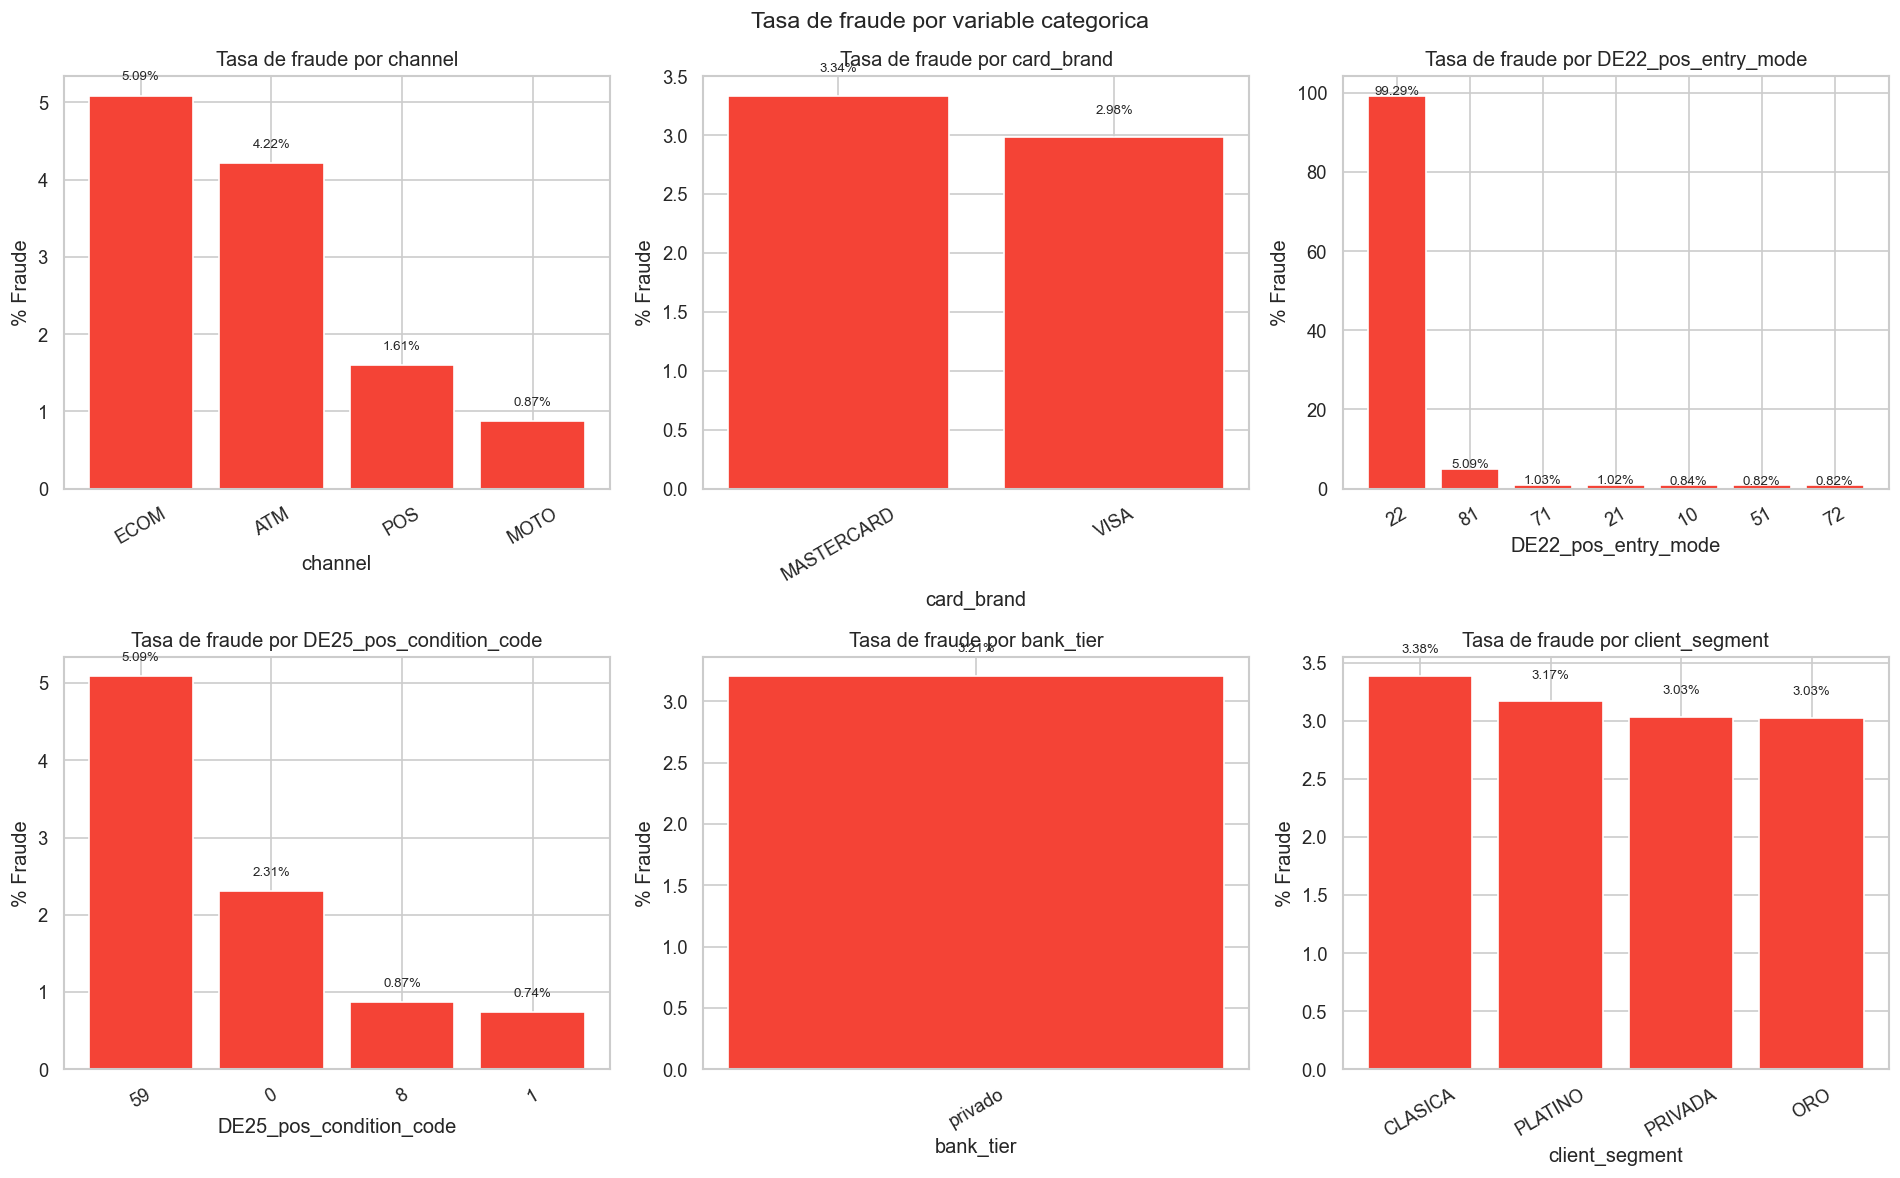

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    fraud_rate = df.groupby(col)[target_col].mean().sort_values(ascending=False)
    axes[i].bar(fraud_rate.index.astype(str), fraud_rate.values * 100, color='#F44336')
    axes[i].set_title(f'Tasa de fraude por {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('% Fraude')
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(fraud_rate.values):
        axes[i].text(j, v * 100 + 0.2, f'{v*100:.2f}%', ha='center', fontsize=8)

plt.suptitle('Tasa de fraude por variable categorica', fontsize=14)
plt.tight_layout()
plt.show()

Las variables categóricas de Brasil muestran patrones consistentes con Bolivia pero con particularidades
propias. ECOM sigue siendo el canal con mayor tasa de fraude (5.09%), aunque ATM presenta una tasa
relativamente alta de 4.22%, superior al 2.84% observado en Bolivia, sugiriendo un perfil de fraude
en cajeros más pronunciado en este banco. `DE22_pos_entry_mode = 22` alcanza 99.29%, incluso mayor que
en Bolivia (98.41%), confirmando que este código debe tratarse como posible leakage en ambos datasets.
`bank_tier` tiene un único valor `privado`, al igual que Bolivia con `vip`, por lo que tampoco aporta
poder discriminativo. `client_segment` muestra diferencias mínimas entre categorías (3.03% a 3.38%),
siendo una variable de bajo aporte predictivo para este banco.

# Distribucion Temporal del Fraude

# Decision de Estrategia de Balanceo

# Conclusión del EDA de Brasil

# Conclusión del EDA de Bolivia

El análisis exploratorio reveló un dataset con desbalanceo severo de 19.33:1, donde el fraude representa
solo el 4.92% de las transacciones. Las variables con mayor poder discriminativo son el monto de la
transacción (diferencia de ~178% entre clases), `distance_from_home_km` (68%) y el canal ECOM (8.02%
de tasa de fraude). Se identificó `DE22_pos_entry_mode = 22` y `DE39_response_code` como posibles
casos de data leakage que deberán excluirse o tratarse con cuidado. La distribución temporal es estable
entre meses, lo que favorece la generalización del modelo sobre Junio como set de test. Como estrategia
de balanceo se utilizará `scale_pos_weight = 19.33` como línea base, explorando oversampling y
undersampling como alternativas durante la etapa de optimización.